In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1775662427.205743   16754 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775662427.229612   16754 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775662427.635089   16754 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# -----------------------------
# Reproducibility & GPU setup
# -----------------------------
RNG_SEED = 42
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"[GPU] Memory growth setup failed: {e}")

W0000 00:00:1775662427.876917   16754 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# -----------------------------
# 1) Load & preprocess MNIST
# -----------------------------
# MNIST: 60k train, 10k test; images 28x28 uint8, labels 0..9
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1] and add channel dimension
x_train = (x_train.astype("float32") / 255.0)[..., None]  # (60000, 28, 28, 1)
x_test  = (x_test.astype("float32") / 255.0)[..., None]   # (10000, 28, 28, 1)

num_classes = 10
input_shape = (28, 28, 1)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")


Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


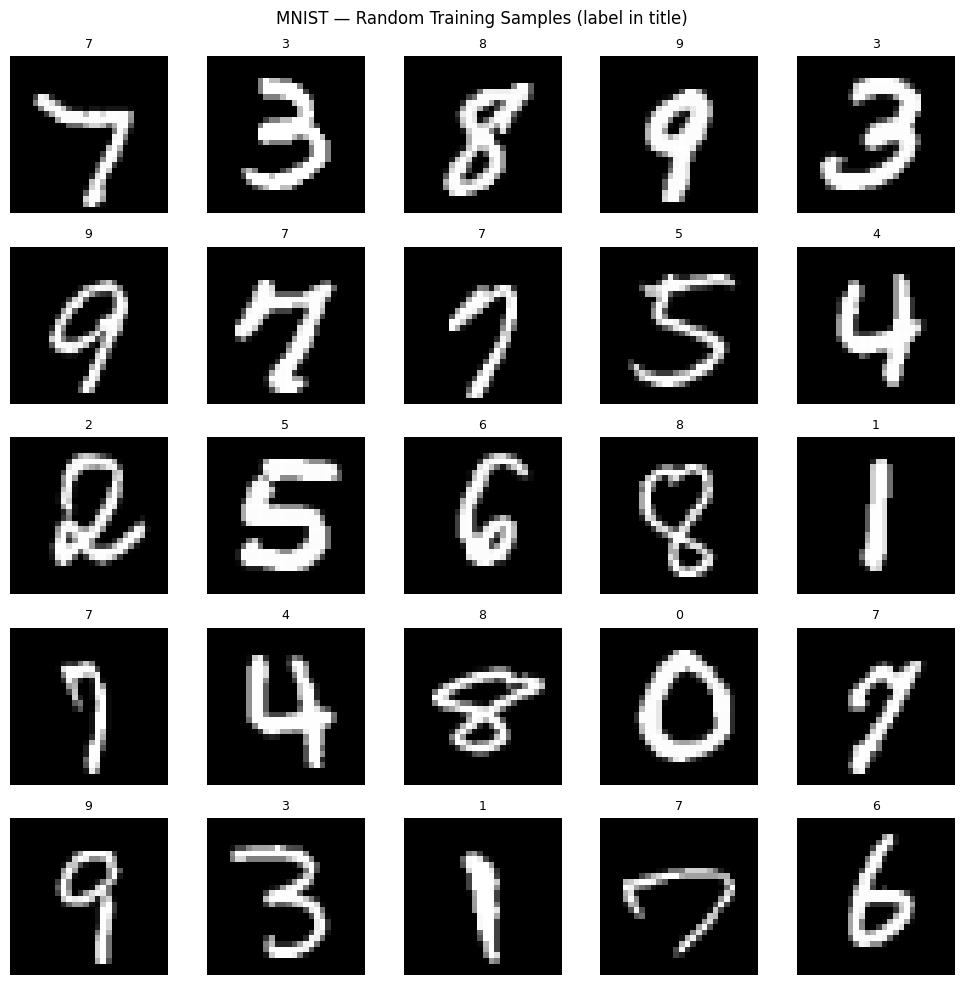

In [4]:
# --- Quick peek: show some training images (place this right after data loading/preprocessing) ---
n = 25  # how many figures to show (e.g., 25 -> 5x5 grid)
idx = np.random.choice(len(x_train), size=n, replace=False)

rows = cols = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 10))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_train[k].squeeze(), cmap="gray")
    plt.title(str(y_train[k]), fontsize=9)
    plt.axis("off")
plt.suptitle("MNIST — Random Training Samples (label in title)")
plt.tight_layout()
plt.show()

In [5]:
# -----------------------------
# 2) Build CNN model
# -----------------------------
K1 = (3, 3)  # kernel size for first conv block
K2 = (3, 3)  # kernel size for second conv block
P1 = (2, 2)  # pool size for first MaxPooling
P2 = (2, 2)  # pool size for second MaxPooling

def build_model():
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=K1, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=K1, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=P1),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=K2, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=K2, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=P2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
        #if we wanted to make numerical prediction instead, we could use a differnt activation function
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├

In [6]:

# -----------------------------
# 3) Train with validation split & callbacks
# -----------------------------


history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=1024,
    validation_split=0.1,     # 54k train / 6k val
    verbose=1
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - accuracy: 0.3944 - loss: 1.7198 - val_accuracy: 0.2275 - val_loss: 2.1447
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.6811 - loss: 0.8669 - val_accuracy: 0.2152 - val_loss: 2.0910
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - accuracy: 0.7949 - loss: 0.5673 - val_accuracy: 0.3412 - val_loss: 1.8514
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.8557 - loss: 0.4097 - val_accuracy: 0.6502 - val_loss: 1.5158
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - accuracy: 0.8806 - loss: 0.3355 - val_accuracy: 0.8062 - val_loss: 1.1869
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 201ms/step - accuracy: 0.9022 - loss: 0.2810 - val_accuracy: 0.8500 - val_loss: 0.8743
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - accuracy: 0.9114 - loss: 0.2566 - val_accuracy: 0.9787 - val_loss: 0.4401
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - accuracy: 0.9188 - loss: 0.2388 - val_accu


[Test] Loss: 0.0555  |  Accuracy: 0.9869

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.9809    0.9949    0.9878       980
           1     0.9878    0.9982    0.9930      1135
           2     0.9913    0.9893    0.9903      1032
           3     0.9804    0.9921    0.9862      1010
           4     0.9948    0.9817    0.9882       982
           5     0.9909    0.9798    0.9853       892
           6     0.9947    0.9854    0.9900       958
           7     0.9697    0.9951    0.9822      1028
           8     0.9938    0.9846    0.9892       974
           9     0.9868    0.9653    0.9760      1009

    accuracy                         0.9869     10000
   macro avg     0.9871    0.9866    0.9868     10000
weighted avg     0.9870    0.9869    0.9869     10000



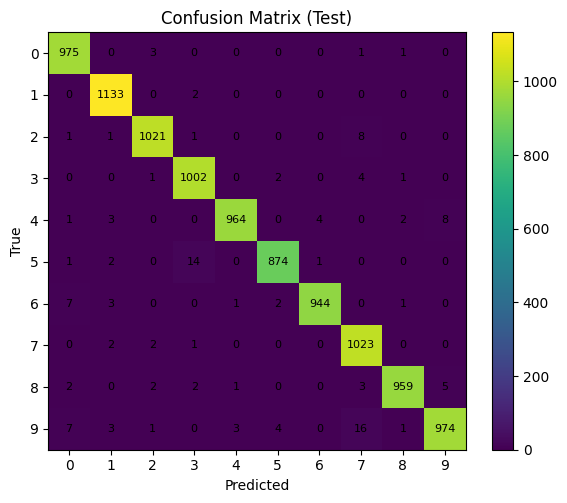

In [7]:
# -----------------------------
# 4) Evaluate on test set
# -----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n[Test] Loss: {test_loss:.4f}  |  Accuracy: {test_acc:.4f}")

# Predictions for detailed metrics
y_prob = model.predict(x_test, verbose=0)
y_pred = y_prob.argmax(axis=1)

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
# annotate counts
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

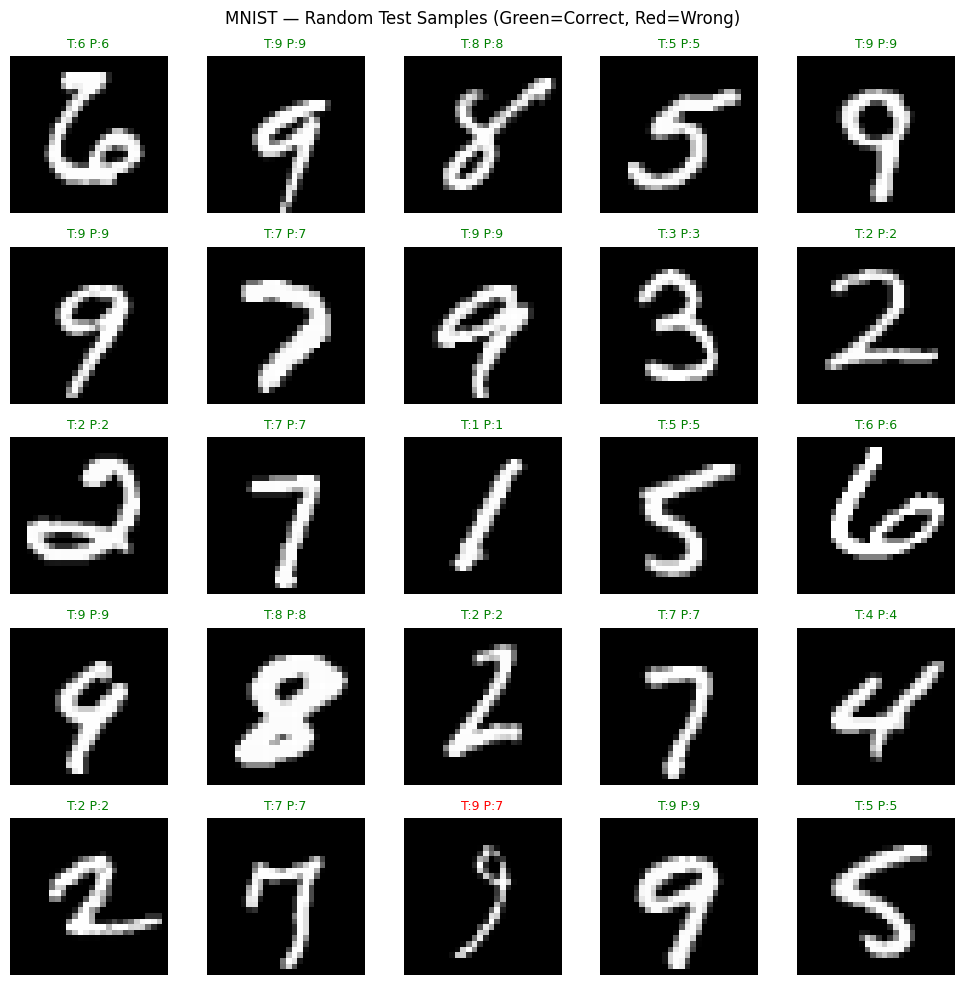

In [8]:
# -----------------------------
# 5) Sample predictions visualization
# -----------------------------
def show_samples(images, true_labels, pred_labels, n=25):
    idx = np.random.choice(len(images), size=n, replace=False)
    plt.figure(figsize=(10,10))
    for k, i in enumerate(idx, 1):
        plt.subplot(5,5,k)
        plt.imshow(images[i].squeeze(), cmap="gray")
        color = "green" if true_labels[i] == pred_labels[i] else "red"
        plt.title(f"T:{true_labels[i]} P:{pred_labels[i]}", color=color, fontsize=9)
        plt.axis("off")
    plt.suptitle("MNIST — Random Test Samples (Green=Correct, Red=Wrong)")
    plt.tight_layout()
    plt.show()

show_samples(x_test, y_test, y_pred, n=25)